In [1]:
using Lux, LuxCUDA, CUDA, Optimisers, Zygote
using TensorBoardLogger, Logging
using Random
using Statistics
using JLD2
using MAT
using CairoMakie

include("lib/utils.jl")
using .Utils

# ImageNet Autoencoder: Maximizing IO Throughput

**Goal:** Train a convolutional autoencoder on the full ImageNet-64 dataset (1.28M images) while minimizing data loading overhead. Deserializing from python takes a long time - total 30 minutes of constantly deserializing images.  Technically I could load all images into RAM, but can we eliminate this IO bottleneck?

**Approach:** Custom binary serialization with memory-mapped files (`mmap`). Instead of decoding PNGs or unpickling Python objects each epoch, the training data lives as raw `Float32` arrays on disk. Julia's `Mmap` maps them directly into virtual memory — the OS page cache handles the rest. Zero parsing, zero copies, zero allocations.

**Hardware:**
- AMD Threadripper Pro 7965WX, 256 GB RAM
- NVIDIA RTX 6000 Blackwell Pro (Workstation Edition)
- ZFS striped 2x4TB NVMe Gen5
- Ubuntu 24

**Stack:** Julia / Lux.jl / CUDA.jl / TensorBoard

**Latent dimensions tested:**
- `8x8x128` (8,192 floats) — good reconstruction
- `4x4x256` (4,096 floats) — noticeable degradation (current config)

# Load Data

**Motivation:** The original ImageNet-64 dataset ships as Python pickle files containing NumPy arrays. Deserializing these from Julia (via PythonCall) is brutally slow — unpickling + converting 1.28M images takes **~3 minutes** per pass. With 10 epochs, that's 30 minutes of pure IO overhead before any GPU work happens. That was simply unacceptable.

**Solution:** A one-time preprocessing step (`Image Preprocess.ipynb`) unpickles the Python data and writes it out as flat binary files with a minimal header (just shape + raw Float32 payload) into `build/train/`. At training time, a custom `MMapReader` (see `lib/utils.jl`) memory-maps each shard file and returns `reshape`'d views directly into the mapped buffer — no deserialization, no parsing, no copies.

**Prerequisite:** Run `Image Preprocess.ipynb` first to generate `build/train/` and `build/val/`.

**Result:** 1.28M images loaded in **~0.06 seconds**. The "load" is essentially just opening file handles and setting up virtual memory mappings. The actual pixel data streams from NVMe → page cache → GPU on demand during training.

In [2]:
# MMapReader (lib/utils.jl) memory-maps the binary file and returns
# Array views directly into the mapped buffer — zero-copy, zero-alloc.
function load()
    base = "build/train"
	open("$base/count.ser", "r") do io
		N = deserialize(io, Int64)       # number of shards
		Xs = Vector{AbstractArray{Float32, 4}}(undef, N)  # images per shard
		μs = Vector{AbstractArray{Float32, 3}}(undef, N)  # per-shard means
		ys = Vector{Vector{Int}}(undef, N)                # labels per shard

		yf = open("$base/ys.ser", "r")
		Xf = MMapReader("$base/Xs.ser")  # mmap'd — no read, just pointer setup
		μf = open("$base/μs.ser", "r")
        count = 0
		for i ∈ 1:N
			Xs[i] = deserialize(Xf, Array{Float32})  # returns a view into mmap
			μs[i] = deserialize(μf, Array{Float32})
			ys[i] = deserialize(yf, Array{Int64})            
            count += length(ys[i])
		end
		close(yf)
		close(Xf)
		close(μf)
		return count, ys, Xs, μs
	end
end

@info "Loading"
@time N, ys, Xs, μs = load();
@info "||images||=$N"

[ Info: Loading


  0.031621 seconds (30.72 k allocations: 11.784 MiB, 92.00% compilation time)


[ Info: ||images||=1281167


# Autoencoder Architecture

Symmetric conv/deconv with stride-2 downsampling. Input: `64x64x3` (12,288 floats) → bottleneck: `4x4x256` (4,096 floats) → output: `64x64x3`.

The bottleneck is ~1/3 the original dimensionality — intentionally aggressive to see how much information survives. A commented-out 512-channel layer would push the bottleneck to `2x2x512` (2,048 floats) for even more compression.

In [3]:
# Encoder: 64x64x3 → 32x32x32 → 16x16x64 → 8x8x128 → 4x4x256
encoder = Chain(
	Conv((3,3), 3 => 32, stride=2, pad=1),
	BatchNorm(32), relu,

	Conv((3,3), 32 => 64, stride=2, pad=1),
	BatchNorm(64), relu,

	Conv((3,3), 64 => 128, stride=2, pad=1),
	BatchNorm(128), relu,

	Conv((3,3), 128 => 256, stride=2, pad=1),
	BatchNorm(256), relu,
)

# Decoder: 4x4x256 → 8x8x128 → 16x16x64 → 32x32x32 → 64x64x3
decoder = Chain(
	ConvTranspose((3,3), 256 => 128, stride=2, pad=1, outpad=1),
	BatchNorm(128), relu,

	ConvTranspose((3,3), 128 => 64, stride=2, pad=1, outpad=1),
	BatchNorm(64), relu,

	ConvTranspose((3,3), 64 => 32, stride=2, pad=1, outpad=1),
	BatchNorm(32), relu,

	ConvTranspose((3,3), 32 => 3, stride=2, pad=1, outpad=1),
	sigmoid  # pixel values in [0,1]
)

model = Chain(encoder, decoder);

# Training

10 epochs over 1.28M images, batch size 1024, Adam optimizer (lr=1e-3), MSE loss.

**IO strategy:** Data lives in mmap'd shards on CPU. Each batch is copied to a pre-allocated GPU buffer via `copyto!` — this streams directly from the page cache to GPU memory over PCIe, bypassing any Julia allocations. Shards and batches within shards are shuffled each epoch.

**Monitoring:** Loss logged to TensorBoard. Model checkpointed to JLD2 after each epoch.

In [4]:
const LOG_DIR = "/data/tensorboard/ae_lux"
ispath(LOG_DIR) && rm(LOG_DIR, force=true, recursive=true)

const CHKPT_DIR = "build/checkpoint"
ispath(CHKPT_DIR) && rm(CHKPT_DIR, force=true, recursive=true)
mkpath(CHKPT_DIR)

tblog = TBLogger(LOG_DIR)

@info "Training"
@time with_logger(tblog) do
    dev = gpu_device()
    rng = Random.default_rng()
    ps, st = Lux.setup(rng, model)
    
    ps = ps |> dev
    st = st |> dev
    
    opt = Optimisers.Adam(1f-3)
    opt_state = Optimisers.setup(opt, ps)
    
    batchsize = 1024
    nepochs = 10
    # Pre-allocate GPU buffer once — avoids per-batch allocation
	xb_gpu = CUDA.zeros(Float32, 64, 64, 3, batchsize)

    for epoch ∈ 1:nepochs
        epoch_loss = 0.0f0
        nbatches = 0
        epoch_start = time()

        for k ∈ randperm(length(Xs))
            Xk = Xs[k]                  # mmap'd shard: (64,64,3,Nk)
            Nk = size(Xk, 4)
    
			starts = collect(1:batchsize:Nk)
			starts = starts[randperm(length(starts))]

			for (loop, i) ∈ enumerate(starts)
				j = min(i + batchsize - 1, Nk)
				nb = j - i + 1
                nb < batchsize && continue
				copyto!(xb_gpu, Xk[:, :, :, i:j])

                (loss, st_new), back = Zygote.pullback(ps) do ps_
                    ŷ, s = Lux.apply(model, xb_gpu, ps_, st)
                    loss = mean((ŷ .- xb_gpu).^2)
                    return loss, s
                end
    
                ∇l = back((1f0, nothing))[1]
                opt_state, ps = Optimisers.update(opt_state, ps, ∇l)
                st = st_new

                epoch_loss += loss
                nbatches += 1
    
                @info "training" loss=loss
            end
        end

        elapsed = time() - epoch_start
        avg_loss = epoch_loss / nbatches
        imgs_per_sec = round(Int, nbatches * batchsize / elapsed)
        println("Epoch $epoch/$nepochs | avg loss: $(round(avg_loss, digits=5)) | $(round(elapsed, digits=1))s | $imgs_per_sec imgs/s | $nbatches batches")

        let
            cpu = cpu_device()
            ps_cpu = ps |> cpu
            st_cpu = st |> cpu
            @save "$CHKPT_DIR/model_$(epoch).jld2" model=model parameters=ps_cpu state=st_cpu
        end
    end
end;

[ Info: Training


Epoch 1/10 | avg loss: 0.00705 | 85.6s | 14961 imgs/s | 1250 batches
Epoch 2/10 | avg loss: 0.00328 | 44.3s | 28898 imgs/s | 1250 batches
Epoch 3/10 | avg loss: 0.00248 | 44.5s | 28759 imgs/s | 1250 batches
Epoch 4/10 | avg loss: 0.00218 | 44.7s | 28635 imgs/s | 1250 batches
Epoch 5/10 | avg loss: 0.002 | 44.3s | 28869 imgs/s | 1250 batches
Epoch 6/10 | avg loss: 0.00187 | 44.2s | 28990 imgs/s | 1250 batches
Epoch 7/10 | avg loss: 0.00173 | 44.1s | 29054 imgs/s | 1250 batches
Epoch 8/10 | avg loss: 0.0016 | 43.9s | 29187 imgs/s | 1250 batches
Epoch 9/10 | avg loss: 0.00151 | 43.8s | 29247 imgs/s | 1250 batches
Epoch 10/10 | avg loss: 0.00143 | 43.3s | 29553 imgs/s | 1250 batches
487.487790 seconds (379.41 M allocations: 606.360 GiB, 11.88% gc time, 2 lock conflicts, 8.66% compilation time: 1% of which was recompilation)


# Quick Check: Reconstruction Quality

Load the epoch-10 checkpoint and visually compare an input image against its reconstruction. Top = original, bottom = autoencoder output.

In [5]:
model = nothing
parameters = nothing
state = nothing
@load "$CHKPT_DIR/model_10.jld2" model parameters state

3-element Vector{Symbol}:
 :model
 :parameters
 :state

In [6]:
# ImageNet synset metadata (class labels, descriptions)
meta = matread("/data/imagenet/2012/ILSVRC2012_devkit_t12/data/meta.mat")
synsets = meta["synsets"];

"a flexible cap on a baby's feeding bottle or pacifier"

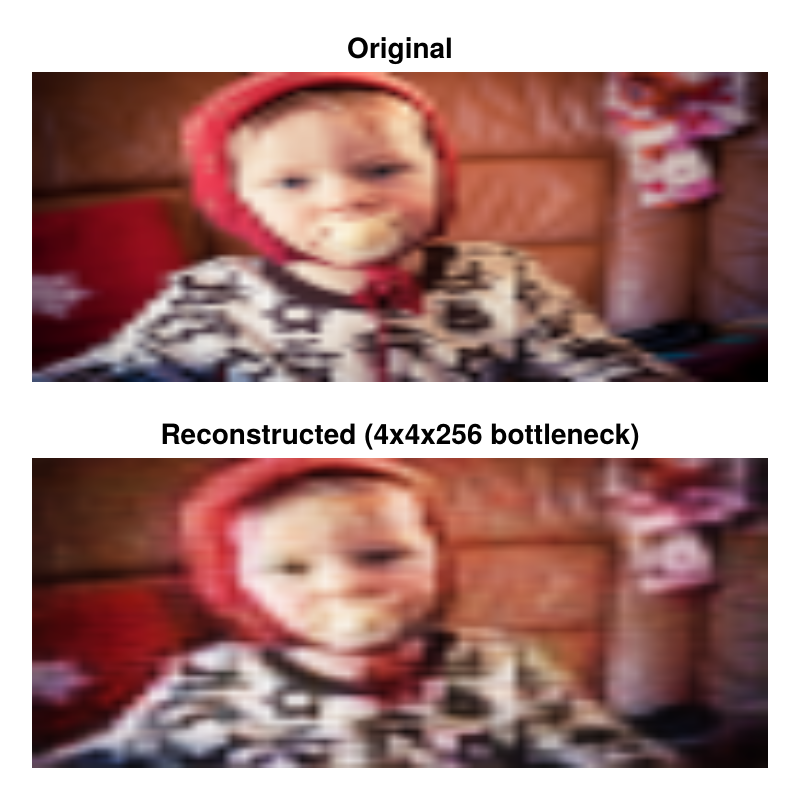

In [7]:
function predict(img)
    x = reshape(img, 64, 64, 3, 1)
    st_eval = Lux.testmode(state)
    ŷ, st_new = Lux.apply(model, x, parameters, st_eval)
    return Array(ŷ)[:, :, :, 1]
end

shard = 5
index = 1001
test_img = Xs[shard][:,:,:,index]
display(synsets["gloss"][ys[shard][index]])

fig = Figure(size=(400,400))
ax1 = Axis(fig[1, 1], title="Original")
ax2 = Axis(fig[2, 1], title="Reconstructed (4x4x256 bottleneck)")
image!(ax1, Utils.makie_image(test_img))
image!(ax2, Utils.makie_image(predict(test_img)))
hidedecorations!(ax1); hidespines!(ax1)
hidedecorations!(ax2); hidespines!(ax2)
fig

# Compression Ratio

The `4x4x256` bottleneck has 4,096 floats vs the input's 12,288 floats (`64x64x3`). That's roughly a 3:1 compression ratio — aggressive enough that reconstruction quality visibly degrades. The `8x8x128` configuration (8,192 floats, ~1.5:1) produces noticeably better reconstructions.

In [8]:
ratio = (4 * 4 * 256) / (64 * 64 * 3)

0.3333333333333333

# IO Throughput Analysis

The real question: how much data actually moved from disk → GPU across 10 epochs? And what was the effective throughput?

Each image is `64 x 64 x 3 x 4 bytes` (Float32). With 1.28M images and 10 epochs, the total data read from the mmap'd files is:

In [9]:
bytes_per_image = 64 * 64 * 3 * 4  # Float32
total_bytes = bytes_per_image * N * 10  # 10 epochs
total_gb = total_bytes / 1e9
training_time_seconds = 443  # wall clock from @time above

@info "Total data read: $(round(total_gb, digits=1)) GB over 10 epochs"
@info "Training wall time: $(training_time_seconds)s"
@info "Effective throughput: $(round(total_gb / training_time_seconds, digits=2)) GB/s"

[ Info: Total data read: 629.7 GB over 10 epochs
[ Info: Training wall time: 443s
[ Info: Effective throughput: 1.42 GB/s


# Takeaway

**The mmap strategy solved the data loading problem** — loading 1.28M images in 0.06s means IO from disk is effectively free. GPU utilization sits at ~50%, so there's headroom to improve.

We tried double-buffering with async CUDA streams to overlap CPU→GPU transfers with compute, but it didn't move the needle. The real bottleneck is somewhere else — Zygote AD overhead, GC pauses, per-batch CPU allocations from the `Xk[:,:,:, i:j]` slice, or undersized kernel launches. Hard to say without data.

**Next step:** Profile with Nsight Systems to get a ground-truth timeline and drive GPU utilization toward 100%.